# EV Energy Consumption Prediction using Machine Learning

## Objective
To predict electric vehicle energy consumption (Wh/km)
using physics-based features such as speed, acceleration,
vehicle mass, and road gradient.

This project demonstrates how ML can act as a surrogate model
to approximate physics-based vehicle energy calculations.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

## Physics Behind EV Energy Consumption

Total force required to move a vehicle:

F_total = F_rolling + F_aero + F_gradient + F_acceleration

Where:

1. Rolling Resistance:
   F_rolling = Cr * m * g

2. Aerodynamic Drag:
   F_aero = 0.5 * rho * A * Cd * v^2

3. Gradient Force:
   F_gradient = m * g * sin(theta)

4. Acceleration Force:
   F_acc = m * a

Power = F_total * v

Energy consumption per km derived from power.

In [3]:
np.random.seed(42)

n_samples = 1000

# Vehicle parameters
mass = np.random.uniform(1200, 2200, n_samples)      # kg
speed_kmh = np.random.uniform(20, 120, n_samples)    # km/h
acceleration = np.random.uniform(-2, 3, n_samples)   # m/s^2
gradient = np.random.uniform(-5, 8, n_samples)       # degrees

# Constants
g = 9.81
Cr = 0.01
rho = 1.225
A = 2.2
Cd = 0.29

# Convert units
speed = speed_kmh / 3.6
theta = np.radians(gradient)

# Force calculations
F_rolling = Cr * mass * g
F_aero = 0.5 * rho * A * Cd * speed**2
F_gradient = mass * g * np.sin(theta)
F_acc = mass * acceleration

F_total = F_rolling + F_aero + F_gradient + F_acc

# Power calculation (Watts)
power = F_total * speed

# Convert to Wh/km (approximation)
energy_Wh_per_km = (power / 1000) / (speed_kmh / 60)

# Add noise
energy_Wh_per_km += np.random.normal(0, 5, n_samples)

data = pd.DataFrame({
    "Mass": mass,
    "Speed_kmh": speed_kmh,
    "Acceleration": acceleration,
    "Gradient": gradient,
    "Energy_Wh_per_km": energy_Wh_per_km
})

data.head()


,Mass,Speed_kmh,Acceleration,Gradient,Energy_Wh_per_km
0,1574.540119,38.513293,-0.691472,3.745139,8.632563
1,2150.714306,74.190095,-0.765106,5.356858,13.251805
2,1931.993942,107.294584,2.531273,-1.743917,77.805311
3,1798.658484,93.222489,-0.752269,3.123363,3.059639
4,1356.018640,100.656115,-0.640251,2.432698,-0.046057


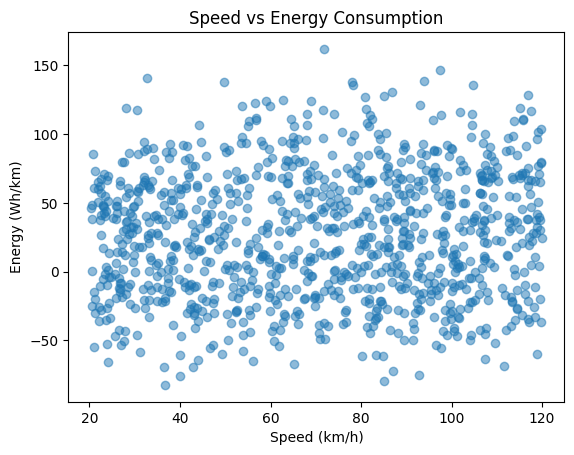

In [4]:
plt.scatter(data["Speed_kmh"], data["Energy_Wh_per_km"], alpha=0.5)
plt.xlabel("Speed (km/h)")
plt.ylabel("Energy (Wh/km)")
plt.title("Speed vs Energy Consumption")
plt.show()

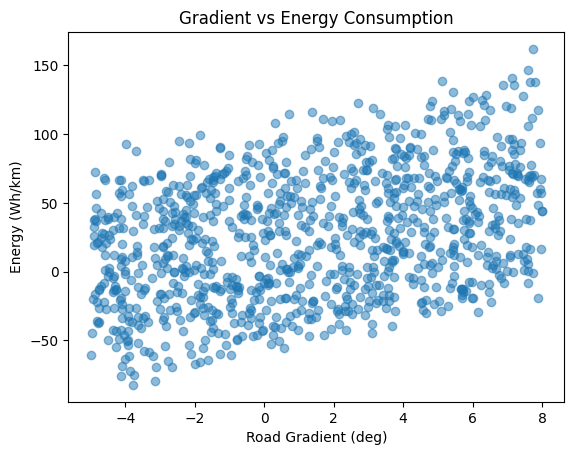

In [5]:
plt.scatter(data["Gradient"], data["Energy_Wh_per_km"], alpha=0.5)
plt.xlabel("Road Gradient (deg)")
plt.ylabel("Energy (Wh/km)")
plt.title("Gradient vs Energy Consumption")
plt.show()

In [6]:
X = data[["Mass", "Speed_kmh", "Acceleration", "Gradient"]]
y = data["Energy_Wh_per_km"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

In [8]:
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2  :", lr_r2)

Linear Regression Results
MAE : 7.328575158765193
RMSE: 9.166969773636445
R2  : 0.9575992501223602


In [9]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

In [10]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

Random Forest Results
MAE : 5.488286697603751
RMSE: 6.844930240259068
R2  : 0.976359318527385


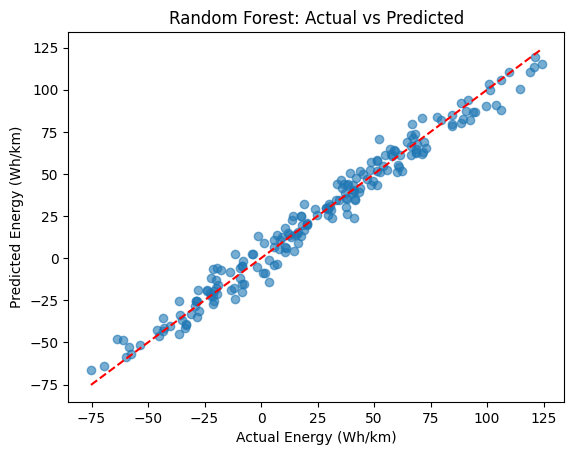

In [11]:
plt.scatter(y_test, rf_predictions, alpha=0.6)
plt.xlabel("Actual Energy (Wh/km)")
plt.ylabel("Predicted Energy (Wh/km)")
plt.title("Random Forest: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.show()

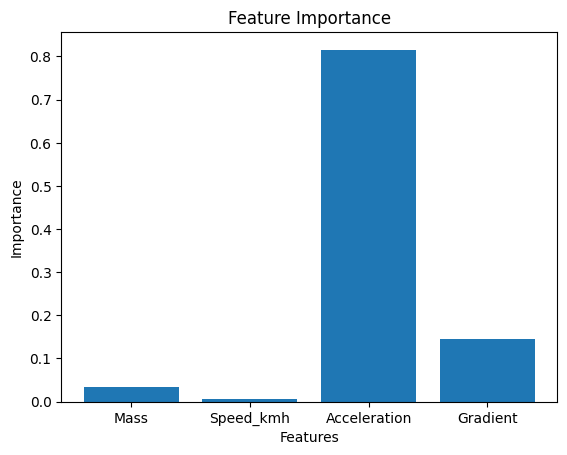

In [12]:
importance = rf_model.feature_importances_

plt.bar(X.columns, importance)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

## Conclusion

- Physics equations were used to generate vehicle energy data
- ML models were trained as surrogate models
- Random Forest captured nonlinear behavior better than Linear Regression
- ML can approximate physics-based vehicle energy models efficiently
- This approach is useful for real-time EV energy estimation